##**NLP Pipeline, Word Embeddings, Neural Nets**

##Twitter Sentiment Analysis Project

Welcome to this Kaggle notebook focusing on NLP Pipeline. We're having a lot to discuss starting from fundamentals of NLP, Text prepocessing techniques, word embedding and different neural networks. We're also going to use Twitter data! In this notebook, we will explore the fascinating world of Natural Language Processing (NLP) by analyzing the sentiment expressed in tweets.

##Objective
Our main objective is to develop machine learning model that can accurately classify tweets as either positive, negative, or neutral based on their content. Sentiment analysis has a wide range of applications, from understanding public opinion to brand monitoring and beyond. We'll try to perform different EDA, Data Preprocessing, Encoding, Embedding and Neural Network Techniques to execute the project.

##Dataset
We will be using a dataset containing tweets collected from Twitter. The dataset includes text, as well as labels indicating the sentiment associated with each tweet. The labels could be 'positive', 'negative'. Positive denoted by 4 and negative by 0. This dataset is having around 1.6 Million Tweets. The dataset is perfetly balanced i.e it has 800k tweets with positive and 800k tweets of negative sentiment
Notebook Structure
This notebook is structured as follows:
```
1. Exploratory Data Analysis
1.1) Loading the dataset
1.2) Data cleaning
1.3) Label distribution
1.4) Creating Word Cloud
1.5) Creating word length distribution
2. Data Preparation for Model Building
2.1) Loading the Dataset
2.2) Data cleaning
3. Trying different Neural Networks
3.1) Splitting dataset into training/testing and validation
3.2) One Hot Encoding + model training
3.3) Count Vectoriser + model training
3.4) TF-IDF + model training
3.5) ANN with Text Sequences
3.5.1) Loading the dataset
3.5.2) Cleaning the dataset
3.5.3) Text encoding
3.5.4) Training the model
3.6) ANN + Embedding with Text Sequences
3.7) LSTM + Embedding with Text Sequences
3.8) GRU + Embedding with Text Sequencess
3.9) Bidirectional + GRU + Embedding with Text Sequences
3.10) Bidirectional + LSTM + Embedding with Text Sequences
3.11) Convolution+ Embedding with Text Sequences
4. Neural Nets with Custom Word2Vec
4.1) Custom Word2Vec in Cov1D
4.1.1) Loading the dataset
4.1.2) Training the Word2Vec
4.1.3) Creating Embedding Matrix
4.1.4) Training the Neural Network
4.2) Custom Word2Vec with Bidirectional + LSTM
```



In [2]:
import os
import re
import nltk
import spacy

import numpy as np
import pandas as pd
from tqdm import tqdm
from wordcloud import WordCloud

import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import plotly.figure_factory as ff
from plotly.subplots import make_subplots

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

!pip install gensim
from gensim.models import Word2Vec

from keras.models import Sequential
from keras.layers import Dense, Flatten
from keras.utils import pad_sequences
from keras.utils import to_categorical

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Dense, Flatten, Dropout, Embedding, GlobalMaxPooling1D, Conv1D, SimpleRNN, LSTM, GRU, Bidirectional

import warnings
warnings.filterwarnings('ignore')

nltk.download('punkt')
nltk.download('stopwords')

nlp = spacy.load("en_core_web_sm")

stop_words = set(stopwords.words('english'))
stop_words = [i for i in stop_words if i not in ['not','until','against','up', 'down', 'no', 'nor',"aren't", 'couldn', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn',
                                                "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 'ma', 'mightn', "mightn't", 'mustn', "mustn't", 'needn', "needn't",
                                                 'shan', "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't", "don't"]]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 47.4 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


##1) Exploratory Data Anlaysis
####1.1) Loading the Dataset

In [3]:
import kagglehub

# Download latest version
path= kagglehub.dataset_download("kazanova/sentiment140")

print("Path to dataset files:", path)

100%|██████████| 80.9M/80.9M [00:01<00:00, 51.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/kazanova/sentiment140/versions/2


In [8]:
df = pd.read_csv('/root/.cache/kagglehub/datasets/kazanova/sentiment140/versions/2/training.1600000.processed.noemoticon.csv', encoding = "latin", header = None, on_bad_lines='skip')
df.rename(columns={0: 'labels', 5: 'tweets'}, inplace=True)
df.drop([1,2,3,4], axis=1, inplace = True)

df['labels'] = df['labels'].replace(4,1)
df = df.sample(frac=1)
df=df.head(10000)
df.head()


,labels,tweets
147079,0,Oh how you confuse me so. On another note. I h...
102366,0,I Miss The Old Cartoons...Animaniacs And All T...
421465,0,thinking about my friends in ohio
510307,0,Stuck in traffic going down to Beirut But alm...
909020,1,"Hey the letter I sent finally came back today,..."


####1.2) Data Cleaning

In [9]:
def get_word_len(tweet):
    return len(tweet.split(' '))

def get_char_len(tweet):
    return len(tweet)
def preprocess_tweet(tweet):
    tweet = tweet.lower()
    tweet = re.sub(r"http\S+|www\S+|https\S+", '', tweet, flags=re.MULTILINE)
    tweet = re.sub(r'@\w+', '', tweet)
    tweet = re.sub(r'[^\w\s#]', '', tweet)
    tokens = [token.lemma_ for token in nlp(tweet)]
    tokens = [token for token in tokens if token not in stop_words]
    tokens = [token for token in tokens if len(token) > 1]
    processed_tweet = ' '.join(tokens)
    return processed_tweet

df['clean_tweets'] = [preprocess_tweet(tw) for tw in tqdm(df['tweets'] ,position=0, leave=True )]
df['tweet_words_length'] = df['clean_tweets'].apply(get_word_len)
df['tweet_chars_length'] = df['clean_tweets'].apply(get_char_len)
df

100%|██████████| 10000/10000 [02:17<00:00, 72.84it/s]


,labels,tweets,clean_tweets,tweet_words_length,tweet_chars_length
147079,0,Oh how you confuse me so. On another note. I h...,oh confuse another note hate see mom frustrate...,9,51
102366,0,I Miss The Old Cartoons...Animaniacs And All T...,miss old cartoonsanimaniac showscartoon jus no...,10,58
421465,0,thinking about my friends in ohio,think friend ohio,3,17
510307,0,Stuck in traffic going down to Beirut But alm...,stick traffic go down beirut almost reach dest...,8,53
909020,1,"Hey the letter I sent finally came back today,...",hey letter send finally come back today ill st...,13,78
...,...,...,...,...,...
1321969,1,Hey @ginoandfran you can also call us &quot;mo...,hey also call quotmonsterinianquot haha sound ...,16,85
121024,0,Bad Bad match! KXIP and RCB need to lose one ...,bad bad match kxip rcb need lose one rr need m...,12,53
1213940,1,Give to charities? http://twollars.com/chariti...,give charity send twollar buy twollar rt ecomo...,8,50
1185861,1,Summer track of 2OO9 = SUMMER GIRLS - STEREOS ...,summer track 2oo9 summer girl stereo lt3 conti...,12,71


####1.3) Label Distribution

In [10]:
positive_count = df[df['labels'] == 1].shape[0]
negative_count = df[df['labels'] == 0].shape[0]

fig = px.pie(values=[df[df['labels'] == 1].shape[0], negative_count], title='Distribution of Positive and Negative Tweets' ,
             names= ['Negative', 'Positive'], hover_name = ['Negative', 'Positive'] , opacity = .9, template = 'simple_white')

fig.show()


####1.4) Creating Word Cloud

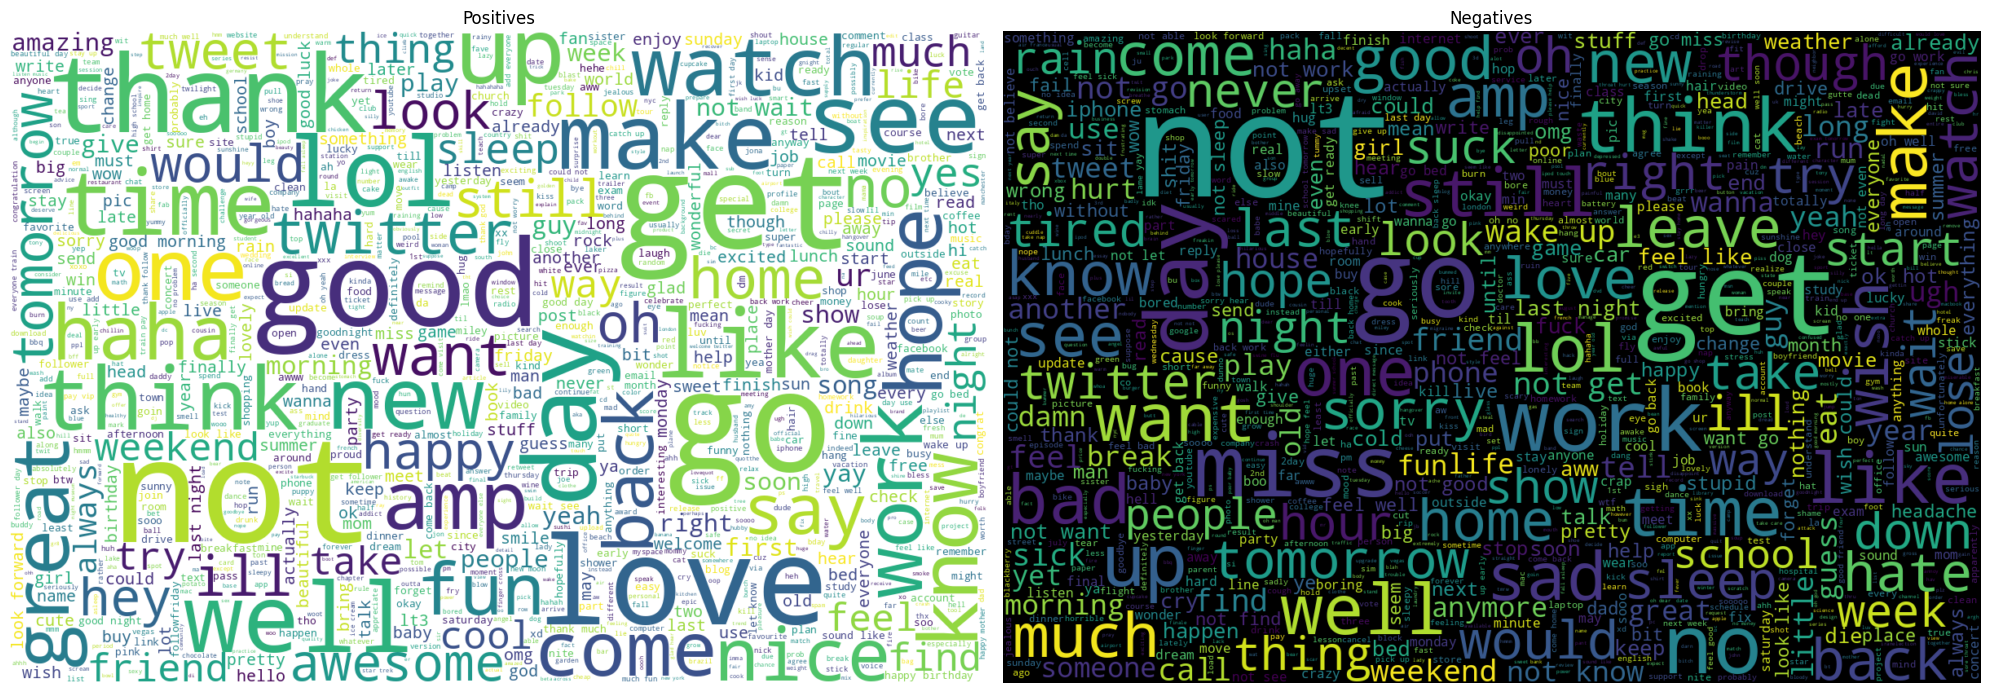

In [11]:
plt.figure(figsize=(20, 8))

STOPWORDS = ['im','today','really','need','tonight']

plt.subplot(1, 2, 1)
wordcloud_1 = WordCloud( width = 1200,  height = 800,  max_words = 1000, contour_width = 2, background_color='white', stopwords = STOPWORDS,max_font_size = 180,
                colormap='viridis').generate(' '.join(df[df['labels'] == 1]['clean_tweets']))
plt.imshow(wordcloud_1, interpolation='bilinear')
plt.axis('off')
plt.title('Positives')


plt.subplot(1, 2, 2)
wordcloud_2 = WordCloud( width = 1200, height = 800, max_words = 1000, contour_width = 2, background_color='black', stopwords = STOPWORDS, max_font_size = 180,
                colormap='viridis').generate(' '.join(df[df['labels'] == 0]['clean_tweets']))
plt.imshow(wordcloud_2, interpolation='bilinear')
plt.axis('off')
plt.title('Negatives')

plt.axis('off')
plt.tight_layout()
plt.show()

####1.5) Creating Word Length Distribution

In [12]:
fig_words=ff.create_distplot([df[df['labels']==1]['tweet_words_length'],df[df['labels']==0]['tweet_words_length']],
                            ['Positive','Negative'],bin_size=25,show_hist=False,show_rug=False)
fig_chars = ff.create_distplot([df[df['labels'] == 1]['tweet_chars_length'], df[df['labels'] == 0]['tweet_chars_length']],
                               ['Positive', 'Negative'], bin_size = 25, show_hist=False, show_rug=False)
fig_chars.update_layout(title="Distribution Plot on Character Count", xaxis_title="Number of Characters", yaxis_title="Frequency")
fig_words.update_layout(title="Distribution Plot on Word Count", xaxis_title="Number of Words", yaxis_title="Frequency")

fig = make_subplots(rows=1, cols=2, subplot_titles=["Word Count", "Character Count"])
fig.add_trace(fig_words['data'][0], row=1, col=1)
fig.add_trace(fig_words['data'][1], row=1, col=1)
fig.add_trace(fig_chars['data'][0], row=1, col=2)
fig.add_trace(fig_chars['data'][1], row=1, col=2)

fig.update_layout(title_text="Distribution Plots - Word Count vs Character Count", showlegend = True , font=dict(family="Arial", size=15, color="black"))
fig.show()

##2) Data Preparation for Model Building
#####2.1) Loading the Dataset

In [13]:
df.head()

,labels,tweets,clean_tweets,tweet_words_length,tweet_chars_length
147079,0,Oh how you confuse me so. On another note. I h...,oh confuse another note hate see mom frustrate...,9,51
102366,0,I Miss The Old Cartoons...Animaniacs And All T...,miss old cartoonsanimaniac showscartoon jus no...,10,58
421465,0,thinking about my friends in ohio,think friend ohio,3,17
510307,0,Stuck in traffic going down to Beirut But alm...,stick traffic go down beirut almost reach dest...,8,53
909020,1,"Hey the letter I sent finally came back today,...",hey letter send finally come back today ill st...,13,78


##3) Trying different Neural Networks
####3.1) Splitting Dataset into Training/Testing and Validation

In [14]:
epochs_=4
seq_len=20
embedding_len=64
batch_size=128
training_size=.8
x_train,x_test,y_train,y_test=train_test_split(df['clean_tweets'],df['labels'],test_size=.2,random_state=42)
x_val,x_test,y_val,y_test=train_test_split(x_test,y_test,test_size=.5,random_state=42)

fig=px.pie(values=[len(x_train),len(x_val),len(x_test)],title='Distribution of Training,Testing and Validation Tweets' ,
             names= ['Training', 'Testing','Validation'], hover_name = ['Training', 'Testing','Validation'] , opacity = .9, template = 'simple_white')
fig.show()
#

####3.2) One Hot Encoded + Model Training

In [15]:
vec=CountVectorizer(binary=True)
vec=vec.fit(df['clean_tweets'])
enc_tweets=vec.transform(df['clean_tweets']).toarray()

x_train, x_test, y_train, y_test = train_test_split(enc_tweets, df['labels'], test_size = training_size, random_state = 42)
x_val, x_test, y_val, y_test = train_test_split(x_test, y_test, test_size=0.5)

model=Sequential()
model.add(Dense(2048,activation='relu',input_shape=(enc_tweets.shape[1],)))
model.add(Dropout(.5))
model.add(Dense(512,activation='relu'))
model.add(Dropout(.5))
model.add(Dense(128,activation='relu'))
model.add(Dropout(.5))
model.add(Dense(1,activation='sigmoid'))

model.compile(loss='binary_crossentropy',optimizer=Adam(learning_rate=0.001),metrics=['accuracy'])

history1=model.fit(x_train,y_train,epochs=epochs_,batch_size=batch_size,validation_data=(x_val,y_val))

print("Model Evaluation on Testing Data : ", round(model.evaluate(x_test,y_test)[1]*100,2))


Epoch 1/4
16/16 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.5495 - loss: 0.6877 - val_accuracy: 0.6712 - val_loss: 0.6668
Epoch 2/4
16/16 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.7560 - loss: 0.5650 - val_accuracy: 0.7122 - val_loss: 0.5876
Epoch 3/4
16/16 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.9025 - loss: 0.2749 - val_accuracy: 0.7023 - val_loss: 0.7568
Epoch 4/4
16/16 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.9720 - loss: 0.0806 - val_accuracy: 0.6817 - val_loss: 1.0223
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - accuracy: 0.6685 - loss: 1.1071
Model Evaluation on Testing Data :  66.85


####3.3) Count Vectorizer + Model Training

In [16]:
vec=CountVectorizer(binary=False)
vec=vec.fit(df['clean_tweets'])
enc_tweets=vec.transform(df['clean_tweets']).toarray()

x_train, x_test, y_train, y_test = train_test_split(enc_tweets, df['labels'], test_size = training_size, random_state = 42)
x_val, x_test, y_val, y_test = train_test_split(x_test, y_test, test_size=0.5)

model=Sequential()
model.add(Dense(2048,activation='relu',input_shape=(enc_tweets.shape[1],)))
model.add(Dropout(.5))
model.add(Dense(512,activation='relu'))
model.add(Dropout(.5))
model.add(Dense(128,activation='relu'))
model.add(Dropout(.5))
model.add(Dense(1,activation='sigmoid'))

model.compile(loss='binary_crossentropy',optimizer=Adam(learning_rate=0.0001),metrics=['accuracy'])

history2=model.fit(x_train,y_train,epochs=epochs_,batch_size=batch_size,validation_data=(x_val,y_val))

print("Model Evaluation on Testing Data : ", round(model.evaluate(x_test,y_test)[1]*100,2))

Epoch 1/4
16/16 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.5075 - loss: 0.6927 - val_accuracy: 0.5930 - val_loss: 0.6908
Epoch 2/4
16/16 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.5675 - loss: 0.6889 - val_accuracy: 0.6478 - val_loss: 0.6881
Epoch 3/4
16/16 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.6050 - loss: 0.6838 - val_accuracy: 0.6675 - val_loss: 0.6836
Epoch 4/4
16/16 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.6665 - loss: 0.6738 - val_accuracy: 0.6750 - val_loss: 0.6760
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - accuracy: 0.6768 - loss: 0.6771
Model Evaluation on Testing Data :  67.68


####3.4) TF-IDF + Model Training

In [17]:
vec=TfidfVectorizer(binary=True)
vec=vec.fit(df['clean_tweets'])
enc_tweets=vec.transform(df['clean_tweets']).toarray()

x_train, x_test, y_train, y_test = train_test_split(enc_tweets, df['labels'], test_size = training_size, random_state = 42)
x_val, x_test, y_val, y_test = train_test_split(x_test, y_test, test_size=0.5)

model=Sequential()
model.add(Dense(2048,activation='relu',input_shape=(enc_tweets.shape[1],)))
model.add(Dropout(.5))
model.add(Dense(512,activation='relu'))
model.add(Dropout(.5))
model.add(Dense(128,activation='relu'))
model.add(Dropout(.5))
model.add(Dense(1,activation='sigmoid'))

model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

history3=model.fit(x_train,y_train,epochs=epochs_,batch_size=batch_size,validation_data=(x_val,y_val))

print("Model Evaluation on Testing Data : ", round(model.evaluate(x_test,y_test)[1]*100,2))

Epoch 1/4
16/16 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.5250 - loss: 0.6913 - val_accuracy: 0.6935 - val_loss: 0.6825
Epoch 2/4
16/16 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.7950 - loss: 0.6041 - val_accuracy: 0.7017 - val_loss: 0.5742
Epoch 3/4
16/16 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.9135 - loss: 0.2475 - val_accuracy: 0.6835 - val_loss: 0.8136
Epoch 4/4
16/16 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.9750 - loss: 0.0746 - val_accuracy: 0.6572 - val_loss: 1.0299
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 105ms/step - accuracy: 0.6810 - loss: 0.9435
Model Evaluation on Testing Data :  68.1


###3.5) ANN with Text Sequencess

#####3.5.1) Loading the Dataset

In [26]:
df = pd.read_csv('/root/.cache/kagglehub/datasets/kazanova/sentiment140/versions/2/training.1600000.processed.noemoticon.csv', encoding = "latin", header = None, on_bad_lines='skip')
df.rename(columns={0: 'labels', 5: 'tweets'}, inplace=True)
df.drop([1,2,3,4], axis=1, inplace = True)

df['labels'] = df['labels'].replace(4,1)
df = df.sample(frac=1)
df=df.head(20000)
df.head()


,labels,tweets
1131493,1,Just packed Alice up for school and now I'm go...
40534,0,@AndrewJace2233 you smoke...a lot.
851155,1,@emilye20 you should put a picture of you!! Wa...
1071207,1,eating a caramel apple pop. Love these things....
64807,0,Its rained for a full week


#####3.5.2) Cleaning the Dataset

In [27]:
df['clean_tweets'] = [preprocess_tweet(tw) for tw in tqdm(df['tweets'] ,position=0, leave=True )]
df['tweet_words_length'] = df['clean_tweets'].apply(get_word_len)
df['tweet_chars_length'] = df['clean_tweets'].apply(get_char_len)
df

100%|██████████| 20000/20000 [04:22<00:00, 76.06it/s] 


,labels,tweets,clean_tweets,tweet_words_length,tweet_chars_length
1131493,1,Just packed Alice up for school and now I'm go...,pack alice up school go dinner alice rachel ni...,13,62
40534,0,@AndrewJace2233 you smoke...a lot.,smokea lot,2,10
851155,1,@emilye20 you should put a picture of you!! Wa...,put picture want study later,5,28
1071207,1,eating a caramel apple pop. Love these things....,eat caramel apple pop love thing jetlag man,8,43
64807,0,Its rained for a full week,rain full week,3,14
...,...,...,...,...,...
1128397,1,@susandamante I love u u r awesomeeeee,love awesomeeeee,2,16
1519314,1,@newtypegirlie it's okay~ I figured that somet...,okay figure something like happen hahaha no wo...,13,73
283125,0,@queenie30 indeed sad. They said it's impossib...,indeed sad say impossible plane onair cos fuel,8,46
1264308,1,@MCRIsAPleasure do it!,,3,2


#####3.5.3) Text Encoding

In [28]:
tokenizer=Tokenizer()
tokenizer.fit_on_texts(df['clean_tweets'])

word_index=tokenizer.word_index
index_word=tokenizer.index_word

sequence=tokenizer.texts_to_sequences(df['clean_tweets'])
enc_tweets=pad_sequences(sequence,maxlen=seq_len,padding='post')

x_train, x_test, y_train, y_test = train_test_split(enc_tweets, df['labels'], test_size = training_size, random_state = 42)
x_val, x_test, y_val, y_test = train_test_split(x_test, y_test, test_size=0.5)

#####3.5.4) Training the Model

In [29]:
model=Sequential()
model.add(Dense(128,activation='relu',input_shape=(seq_len,)))
model.add(Dropout(.5))
model.add(Dense(64,activation='relu'))
model.add(Dropout(.5))
model.add(Dense(32,activation='relu'))
model.add(Dropout(.5))
model.add(Dense(1,activation='sigmoid'))

model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])

history4=model.fit(x_train,y_train,epochs=epochs_,batch_size=batch_size,validation_data=(x_val,y_val))

print("Model Evaluation on Testing Data : ", round(model.evaluate(x_test,y_test)[1]*100,2))

Epoch 1/4
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.4938 - loss: 464.2171 - val_accuracy: 0.5023 - val_loss: 33.1567
Epoch 2/4
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5033 - loss: 229.3243 - val_accuracy: 0.5058 - val_loss: 18.7391
Epoch 3/4
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5050 - loss: 137.0476 - val_accuracy: 0.5064 - val_loss: 11.5135
Epoch 4/4
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5030 - loss: 105.3431 - val_accuracy: 0.5023 - val_loss: 7.8221
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5031 - loss: 7.6797
Model Evaluation on Testing Data :  50.31


#####3.6) ANN + Embedding with Text Sequencess

In [31]:
epochs_ = 10
seq_len = 20
batch_size_ = 64
training_size = .8
embedding_len = 100

model=Sequential()
model.add(Embedding(input_dim=len(word_index)+1,output_dim=embedding_len,input_length=seq_len))
model.add(Flatten())
model.add(Dense(64,activation='relu'))
model.add(Dropout(.5))
model.add(Dense(32,activation='relu'))
model.add(Dropout(.5))
model.add(Dense(1,activation='sigmoid'))

model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])

history5=model.fit(x_train,y_train,epochs=epochs_,batch_size=batch_size,validation_data=(x_val,y_val))

print("Model Evaluation on Testing Data : ", round(model.evaluate(x_test,y_test)[1]*100,2))

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.5073 - loss: 0.6939 - val_accuracy: 0.5418 - val_loss: 0.6920
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5445 - loss: 0.6883 - val_accuracy: 0.5471 - val_loss: 0.6879
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.6363 - loss: 0.6572 - val_accuracy: 0.6346 - val_loss: 0.6432
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8177 - loss: 0.4837 - val_accuracy: 0.6941 - val_loss: 0.5905
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9330 - loss: 0.2223 - val_accuracy: 0.6793 - val_loss: 0.7130
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9730 - loss: 0.0958 - val_accuracy: 0.6719 - val_loss: 0.8885
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.9865 - loss: 0.0525 - val_accuracy: 0.6620 - val_loss: 1.0755
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - accuracy: 0.9893 - loss: 0.0391 - val_accuracy: 0.6670 - v

#####3.7) LSTM + Embedding with Text Sequencess

In [32]:
model=Sequential()
model.add(Embedding(input_dim=len(word_index)+1,output_dim=embedding_len,input_length=seq_len))
model.add(LSTM(units=128,dropout=.2,return_sequences=True))
model.add(LSTM(64))
model.add(Dense(32,activation='relu'))
model.add(Dropout(.5))
model.add(Dense(1,activation='sigmoid'))

model.compile(loss='binary_crossentropy',optimizer=Adam(learning_rate = 0.0001),metrics=['accuracy'])

history6=model.fit(x_train,y_train,epochs=epochs_,batch_size=batch_size,validation_data=(x_val,y_val))

print("Model Evaluation on Testing Data : ", round(model.evaluate(x_test,y_test)[1]*100,2))

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 202ms/step - accuracy: 0.5113 - loss: 0.6929 - val_accuracy: 0.5494 - val_loss: 0.6930
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 234ms/step - accuracy: 0.5150 - loss: 0.6927 - val_accuracy: 0.5213 - val_loss: 0.6927
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 187ms/step - accuracy: 0.5285 - loss: 0.6919 - val_accuracy: 0.5156 - val_loss: 0.6923
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 308ms/step - accuracy: 0.5468 - loss: 0.6901 - val_accuracy: 0.5620 - val_loss: 0.6893
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 283ms/step - accuracy: 0.6102 - loss: 0.6802 - val_accuracy: 0.6471 - val_loss: 0.6677
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 355ms/step - accuracy: 0.7287 - loss: 0.5895 - val_accuracy: 0.6948 - val_loss: 0.5902
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 250ms/step - accuracy: 0.7960 - loss: 0.4706 - val_accuracy: 0.7016 - val_loss: 0.5964
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 256ms/step - accuracy: 0.8290 - loss: 0.4083 - val_accuracy

#####3.8) GRU + Embedding with Text Sequencess

In [33]:
model=Sequential()
model.add(Embedding(input_dim=len(word_index)+1,output_dim=embedding_len,input_length=seq_len))
model.add(GRU(units=128,dropout=.2,return_sequences=True))
model.add(GRU(64))
model.add(Dense(64,activation='relu'))
model.add(Dropout(.5))
model.add(Dense(1,activation='sigmoid'))

model.compile(loss='binary_crossentropy',optimizer=Adam(learning_rate = 0.0001),metrics=['accuracy'])

history7=model.fit(x_train,y_train,epochs=epochs_,batch_size=batch_size,validation_data=(x_val,y_val))

print("Model Evaluation on Testing Data : ", round(model.evaluate(x_test,y_test)[1]*100,2))

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 198ms/step - accuracy: 0.4922 - loss: 0.6934 - val_accuracy: 0.5140 - val_loss: 0.6931
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 293ms/step - accuracy: 0.5100 - loss: 0.6932 - val_accuracy: 0.4855 - val_loss: 0.6935
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 200ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.4856 - val_loss: 0.6935
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 228ms/step - accuracy: 0.4988 - loss: 0.6933 - val_accuracy: 0.4859 - val_loss: 0.6934
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 294ms/step - accuracy: 0.5055 - loss: 0.6932 - val_accuracy: 0.4863 - val_loss: 0.6933
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 435ms/step - accuracy: 0.5020 - loss: 0.6934 - val_accuracy: 0.4874 - val_loss: 0.6933
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 409ms/step - accuracy: 0.5017 - loss: 0.6931 - val_accuracy: 0.4930 - val_loss: 0.6932
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 436ms/step - accuracy: 0.5115 - loss: 0.6927 - val_accurac

#####3.9) Bidirectional + GRU + Embedding with Text Sequencess

In [35]:
model=Sequential()
model.add(Embedding(input_dim=len(word_index)+1,output_dim=embedding_len,input_length=seq_len))
model.add(Bidirectional(GRU(units=128,dropout=.2,return_sequences=True)))
model.add(Bidirectional(GRU(64)))
model.add(Dense(32,activation='relu'))
model.add(Dropout(.5))
model.add(Dense(1,activation='sigmoid'))

model.compile(loss='binary_crossentropy',optimizer=Adam(learning_rate = 0.0001),metrics=['accuracy'])

history8=model.fit(x_train,y_train,epochs=epochs_,batch_size=batch_size,validation_data=(x_val,y_val))

print("Model Evaluation on Testing Data : ", round(model.evaluate(x_test,y_test)[1]*100,2))

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 419ms/step - accuracy: 0.5123 - loss: 0.6927 - val_accuracy: 0.5479 - val_loss: 0.6920
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 586ms/step - accuracy: 0.5435 - loss: 0.6909 - val_accuracy: 0.5451 - val_loss: 0.6902
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 605ms/step - accuracy: 0.5968 - loss: 0.6866 - val_accuracy: 0.5953 - val_loss: 0.6856
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 634ms/step - accuracy: 0.6538 - loss: 0.6745 - val_accuracy: 0.6161 - val_loss: 0.6742
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 354ms/step - accuracy: 0.7082 - loss: 0.6444 - val_accuracy: 0.6568 - val_loss: 0.6442
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 382ms/step - accuracy: 0.7635 - loss: 0.5633 - val_accuracy: 0.6859 - val_loss: 0.5943
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 384ms/step - accuracy: 0.8033 - loss: 0.4588 - val_accuracy: 0.6898 - val_loss: 0.6141
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 381ms/step - accuracy: 0.8487 - loss: 0.3759 - val_accu

#####3.10) Bidirectional + LSTM + Embedding with Text Sequencess

In [36]:
model=Sequential()
model.add(Embedding(input_dim=len(word_index)+1,output_dim=embedding_len,input_length=seq_len))
model.add(Bidirectional(LSTM(units=128,dropout=.2,return_sequences=True)))
model.add(Bidirectional(LSTM(64)))
model.add(Dense(32,activation='relu'))
model.add(Dropout(.5))
model.add(Dense(1,activation='sigmoid'))

model.compile(loss='binary_crossentropy',optimizer=Adam(learning_rate = 0.0001),metrics=['accuracy'])

history9=model.fit(x_train,y_train,epochs=epochs_,batch_size=batch_size,validation_data=(x_val,y_val))

print("Model Evaluation on Testing Data : ", round(model.evaluate(x_test,y_test)[1]*100,2))

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 22s 433ms/step - accuracy: 0.5092 - loss: 0.6931 - val_accuracy: 0.5117 - val_loss: 0.6929
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 406ms/step - accuracy: 0.5165 - loss: 0.6928 - val_accuracy: 0.5121 - val_loss: 0.6926
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 407ms/step - accuracy: 0.5307 - loss: 0.6915 - val_accuracy: 0.5239 - val_loss: 0.6916
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 512ms/step - accuracy: 0.5550 - loss: 0.6894 - val_accuracy: 0.5552 - val_loss: 0.6891
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 24s 752ms/step - accuracy: 0.5980 - loss: 0.6823 - val_accuracy: 0.5924 - val_loss: 0.6798
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 43s 815ms/step - accuracy: 0.6865 - loss: 0.6384 - val_accuracy: 0.6914 - val_loss: 0.5955
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 22s 696ms/step - accuracy: 0.7878 - loss: 0.5015 - val_accuracy: 0.6961 - val_loss: 0.5909
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 790ms/step - accuracy: 0.8257 - loss: 0.4391 - val_accu

#####3.11) Convolution + Embedding with Text Sequencess

In [37]:
model=Sequential()
model.add(Embedding(input_dim=len(word_index)+1,output_dim=embedding_len,input_length=seq_len))
model.add(Conv1D(128,5,activation='relu'))
model.add(GlobalMaxPooling1D())
model.add(Dense(64,activation='relu'))
model.add(Dropout(.5))
model.add(Dense(32,activation='relu'))
model.add(Dropout(.5))
model.add(Dense(1,activation='sigmoid'))

model.compile(loss='binary_crossentropy',optimizer=Adam(learning_rate = 0.0001),metrics=['accuracy'])

history10=model.fit(x_train,y_train,epochs=epochs_,batch_size=batch_size,validation_data=(x_val,y_val))

print("Model Evaluation on Testing Data : ", round(model.evaluate(x_test,y_test)[1]*100,2))

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.4938 - loss: 0.6936 - val_accuracy: 0.4919 - val_loss: 0.6931
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.5060 - loss: 0.6931 - val_accuracy: 0.5049 - val_loss: 0.6927
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - accuracy: 0.5312 - loss: 0.6913 - val_accuracy: 0.5310 - val_loss: 0.6921
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.5510 - loss: 0.6894 - val_accuracy: 0.5310 - val_loss: 0.6913
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.5640 - loss: 0.6886 - val_accuracy: 0.5755 - val_loss: 0.6900
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.5842 - loss: 0.6862 - val_accuracy: 0.5742 - val_loss: 0.6886
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.6202 - loss: 0.6816 - val_accuracy: 0.5966 - val_loss: 0.6861
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.6403 - loss: 0.6746 - val_accuracy: 0.6116 - v

##4) Neural Nets with Custom Word2Vec

######4.1.1)Loading the Dataset

In [38]:
epochs_ = 12
seq_len = 20
batch_size_ = 1024
training_size = .8
embedding_len = 300

def get_word_len(tweet):
    return len(tweet.split(' '))

def get_char_len(tweet):
    return len(tweet)

def preprocess_tweet(tweet):
    tweet = tweet.lower()
    tweet = re.sub(r"http\S+|www\S+|https\S+", '', tweet, flags=re.MULTILINE)
    tweet = re.sub(r'@\w+', '', tweet)
    tweet = re.sub(r'[^\w\s#]', '', tweet)
    tokens = word_tokenize(tweet)
    tokens = [token for token in tokens if token not in stop_words]
    tokens = [token for token in tokens if len(token) > 1]
    processed_tweet = ' '.join(tokens)
    return processed_tweet

df = pd.read_csv('/kaggle/input/sentiment140/training.1600000.processed.noemoticon.csv', encoding = "latin", header = None, on_bad_lines='skip')

df.rename(columns={0: 'labels', 5: 'tweets'}, inplace=True)
df.drop([1,2,3,4], axis=1, inplace = True)

df['labels'] = df['labels'].replace(4,1)

df = df.sample(frac=1)
# df = df.head(10000)

df['clean_tweets'] = [preprocess_tweet(tw) for tw in tqdm(df['tweets'] ,position=0, leave=True )]

tokenizer = Tokenizer()
tokenizer.fit_on_texts(df['clean_tweets'])

word_index = tokenizer.word_index
index_word = tokenizer.index_word

sequences = tokenizer.texts_to_sequences(df['clean_tweets'])
enc_tweets = pad_sequences(sequences, maxlen = seq_len, padding = 'post')
x_train, x_test, y_train, y_test = train_test_split(enc_tweets, df['labels'] , test_size = training_size, random_state = 42)
x_val, x_test, y_val, y_test = train_test_split(x_test, y_test, test_size=0.5)

#####4.1.2) Training the Word2Vec

In [41]:
embedding_len=200
nltk.download('punkt_tab')
word2vec=Word2Vec(list(map(lambda x:word_tokenize(x),df['clean_tweets'])),vector_size=embedding_len,window=5,workers=8,min_count=1)

print("Vocabulary Size:" , len(word2vec.wv.key_to_index))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Vocabulary Size: 20810


#####4.1.3) Creating Embedding Matrix

In [50]:
embedding_matrix = np.zeros((len(word2vec.wv.key_to_index)+1, embedding_len))

for word, token in tokenizer.word_index.items():
    if word2vec.wv.__contains__(word):
        embedding_matrix[token] = word2vec.wv.__getitem__(word)

print("Embedding Matrix Shape:", embedding_matrix.shape)

Embedding Matrix Shape: (20811, 200)


#####4.1.4) Training the Neural Network

In [51]:
model = Sequential()

model.add(Embedding(input_dim = len(word2vec.wv.key_to_index)+1,output_dim = embedding_len,weights=[embedding_matrix],input_length = seq_len,trainable = False))
model.add(Conv1D(128, 5, activation='relu'))
model.add(GlobalMaxPooling1D())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer = Adam(learning_rate = 0.0001), metrics=['accuracy'])

history_11 = model.fit(x_train, y_train, epochs = epochs_, batch_size = batch_size_, validation_data=(x_val, y_val))
print('\n')
print("Model Evaluation on Testing Data : ", round(model.evaluate(x_test,y_test)[1]*100,2))

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - accuracy: 0.5013 - loss: 0.7072 - val_accuracy: 0.5255 - val_loss: 0.6911
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 77ms/step - accuracy: 0.5295 - loss: 0.6944 - val_accuracy: 0.5433 - val_loss: 0.6882
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.5215 - loss: 0.6946 - val_accuracy: 0.5406 - val_loss: 0.6893
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.5282 - loss: 0.6911 - val_accuracy: 0.5385 - val_loss: 0.6891
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.5315 - loss: 0.6897 - val_accuracy: 0.5437 - val_loss: 0.6876
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.5410 - loss: 0.6880 - val_accuracy: 0.5437 - val_loss: 0.6873
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.5412 - loss: 0.6901 - val_accuracy: 0.5480 - val_loss: 0.6872
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.5408 - loss: 0.6881 - val_accuracy: 0.5452 - 

###4.2) Custom Word2Vec with Bidirectional + LSTM

In [53]:
model = Sequential()

model.add(Embedding(input_dim = len(word2vec.wv.key_to_index)+1,output_dim = embedding_len,weights=[embedding_matrix],input_length = seq_len,trainable = False))
model.add(Bidirectional(LSTM(100, dropout=0.3, return_sequences=True)))
model.add(Bidirectional(LSTM(100, dropout=0.3, return_sequences=True)))
model.add(GlobalMaxPooling1D())
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer = Adam(learning_rate = 0.0001), metrics=['accuracy'])

history_12 = model.fit(x_train, y_train, epochs = epochs_, batch_size = batch_size_, validation_data=(x_val, y_val))
print('\n')
print("Model Evaluation on Testing Data : ", round(model.evaluate(x_test,y_test)[1]*100,2))

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 32s 280ms/step - accuracy: 0.5067 - loss: 0.6938 - val_accuracy: 0.5361 - val_loss: 0.6906
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 25s 404ms/step - accuracy: 0.5200 - loss: 0.6917 - val_accuracy: 0.5321 - val_loss: 0.6895
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 19s 302ms/step - accuracy: 0.5297 - loss: 0.6903 - val_accuracy: 0.5240 - val_loss: 0.6912
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 33s 522ms/step - accuracy: 0.5415 - loss: 0.6906 - val_accuracy: 0.5350 - val_loss: 0.6891
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 31s 498ms/step - accuracy: 0.5420 - loss: 0.6901 - val_accuracy: 0.5409 - val_loss: 0.6877
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 265ms/step - accuracy: 0.5403 - loss: 0.6894 - val_accuracy: 0.5383 - val_loss: 0.6878
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 273ms/step - accuracy: 0.5458 - loss: 0.6879 - val_accuracy: 0.5420 - val_loss: 0.6874
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 332ms/step - accuracy: 0.5443 - loss: 0.6887 - val_accu